# :)

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.utils.parameters import (
    mcwf_dt_from_scales,
    omega_c,
    scaled_N_Gamma,
)
from common.utils.phases import default_three_phase_protocol
from parser.moments import MomentSeries, SimulationMetadata

from parser.mcwf import MCWFSolverParameters
from solvers.mcwf.ensamble_sim import run_trajectory_ensemble
from solvers.mcwf.j_moments import compute_mcwf_j_moments
from post_analysis import compute_mfe_residuals
from common.plotting import plot_mfe_residuals

%reload_ext autoreload
%autoreload 2

output_dir = repo_root / "output"

/Users/ashar/.pyenv/versions/cavity-OAT_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### :)

simulate trajectories: 100%|██████████| 1000/1000 [00:22<00:00, 43.87it/s]

Simulation step summary (avg per trajectory): total steps=12986.97, steps without precompute=512.96



compute_mcwf_j_moments: 100%|██████████| 1000/1000 [00:06<00:00, 148.59it/s]


Residual L1 norm
Phase 1 - end: 1.029e-02, min: 0.000e+00
Phase 2 - end: 3.719e-03, min: 4.408e-04
Phase 3 - end: 1.403e-04, min: 1.403e-04


simulate trajectories: 100%|██████████| 1000/1000 [00:30<00:00, 32.45it/s]

...

Residual L1 norm
Phase 1 - end: 1.678e-02, min: 0.000e+00
Phase 2 - end: 4.170e-03, min: 2.005e-03
Phase 3 - end: 1.164e-06, min: 1.164e-06


simulate trajectories: 100%|██████████| 1000/1000 [06:05<00:00,  2.74it/s]

Simulation step summary (avg per trajectory): total steps=101365.72, steps without precompute=569.71



compute_mcwf_j_moments: 100%|██████████| 1000/1000 [00:07<00:00, 131.36it/s]


Residual L1 norm
Phase 1 - end: 1.306e-02, min: 0.000e+00
Phase 2 - end: 3.579e-03, min: 1.673e-03
Phase 3 - end: 6.138e-07, min: 6.138e-07


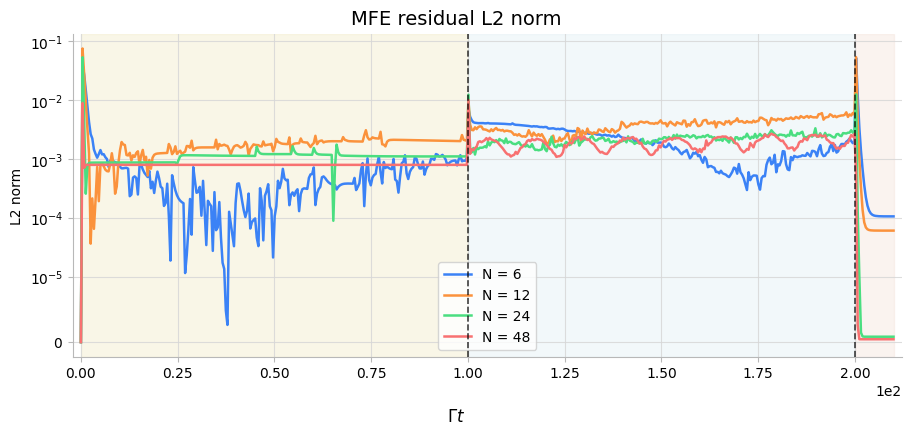

In [2]:
# common fixed
Gamma = 1; num_snapshots=500
# param
dN = 0
omega_i = [0.7]
ntraj = 1000

# protocol durations
T1 = 100.0
T2 = 100.0
T3 = 10.0


axes_mfe_res = None
for i, NJi in enumerate((3,6,12,24)):
    Ni = [NJi,NJi]

    # Model and parameters
    Omega_factor = 0.1
    Omega0 = scaled_N_Gamma(Omega_factor, sum(Ni), Gamma)
    delta_factor = 0.01
    delta0 = scaled_N_Gamma(delta_factor, sum(Ni), Gamma)
    dt = mcwf_dt_from_scales(Omega0, delta0, sum(Ni), Gamma)

    phase_protocol = default_three_phase_protocol(
        durations=(T1, T2, T3),
        delta0=delta0,
        Omega0=Omega0,
    )
    simulation_metadata = SimulationMetadata(
        Ni=tuple(Ni),
        omega_i=tuple(omega_i),
        Gamma=Gamma,
        phase_protocol=phase_protocol,
    )


    # moment initialization
    mcwf_moments = MomentSeries(
        num_snapshots=num_snapshots,
        metadata=simulation_metadata,
    )

    # Define method parameters and simulate using Monte-Carlo wave function method
    mcwf_parameters = MCWFSolverParameters(
        Ni=simulation_metadata.Ni,
        omega_i=simulation_metadata.omega_groups,
        Gamma=simulation_metadata.Gamma,
        phase_protocol=simulation_metadata.phase_protocol,
        dN=dN,
        sector_distribution="binomial",
        dt=dt,
        shifted_jump_operator=True,
    )
    mcwf_ensemble = run_trajectory_ensemble(
        mcwf_parameters,
        t_eval=mcwf_moments.t,
        seed=1234,
        ntraj=ntraj,
        n_processes=8,
        )

    # compute moments
    mcwf_moments.J = compute_mcwf_j_moments(
        mcwf_ensemble,
        n_processes=-1,
    )

    # mfe resiudals
    mcwf_moments.mfe_residuals = compute_mfe_residuals(
        mcwf_moments.J,
        metadata=mcwf_moments.metadata,
    )

    # plot mfe residuals
    fig, axes_mfe_res = plot_mfe_residuals(
        mcwf_moments.mfe_residuals,
        show_components=False,
        phase_protocol=mcwf_moments.metadata.phase_protocol,
        label=f"N = {2*NJi}",
        colour_family_index=i,
        shade_index=2,
        linestyle="-",
        symlog=True,
        axes=axes_mfe_res,
        output_path=f"{output_dir}/finite_size_effects/mfe_residuals_Ni.png",
    )